In [19]:
import os
os.environ["OMP_NUM_THREADS"] = "1"     # agama
os.environ["MKL_NUM_THREADS"] = "1"     # numpy, scipy
os.environ["OPENBLAS_NUM_THREADS"] = "1"    # numpy
os.environ["NUMEXPR_NUM_THREADS"] = "1"     # pandas

import agama
import torch 
import numpy as np
from scipy import integrate
# from scipy.stats import wasserstein_distance_nd
from astropy import units as u

from sbi.utils import BoxUniform

from sbi.inference import SNLE, simulate_for_sbi, prepare_for_sbi


from sbi.utils import likelihood_nn

from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
import pickle
import matplotlib.pyplot as plt
from galaxy_generation import generate_galaxy_multiple, transform_params, _generate_galaxy
from prior_generation import generate_prior
from standardization import standardize
from object_handler import load_csv, load_pickle, save_csv, load_galaxies, load_h5
from model import prep_data
import h5py
# from wasserstein_distance_nd import wasserstein_distance_nd 
import corner

torch.set_num_threads(4)


In [18]:
train_theta="./model_1/train_theta.csv"
train_x = "./model_1/train_x.csv"
t, x = prep_data(train_theta, train_x, standardization=True)

In [21]:
x.shape

AttributeError: 'tuple' object has no attribute 'shape'

In [3]:
def density(x: np.ndarray, 
            theta: torch.Tensor) -> np.ndarray:
    """
    Calculate density using GNFW profile as a function of r
    
    Params:
    - x: the value at which the function must be computed at (log_r_div_rstar)
    - theta: MCMC samples of the posterior
    """
    theta = np.array(transform_params(theta))
    
    alpha = theta[:,0]
    beta = theta[:,1]
    gamma = theta[:,2]
    p_0 = theta[:,3]
    r_s = theta[:,4]
    r_star = theta[:,5]
    
    r = 10 ** x * r_star

    rho = p_0 * (r / r_s) ** -gamma * (1 + (r / r_s) ** alpha) ** (-(beta-gamma)/alpha)
    
    return np.log10(rho)

In [8]:
cored_params = load_csv("mass_density_samples_model_14_core.csv", "Tensor")


In [11]:
(cored_params[:,1] + cored_params[:,0]).T


/tmp/ipykernel_1519478/3037505097.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /croot/pytorch-select_1717607455294/work/aten/src/ATen/native/TensorShape.cpp:3675.)
  (cored_params[:,1] + cored_params[:,0]).T


tensor([6.8871, 6.8602, 6.9556,  ..., 7.3751, 7.3311, 7.5828])

In [12]:
np.quantile(cored_params, [0.1,0.2], axis=0)

array([[ 7.19623461, -0.40459775, -0.86520606,  0.22706032],
       [ 7.34835968, -0.34937022, -0.74839115,  0.25332154]])

In [51]:
test_theta_raw = load_csv("model_1/test_theta.csv", "Tensor")
test_x_raw = load_csv("model_1/test_x.csv", "Tensor")

In [4]:
from mcmc import prep_posterior
# MCMC settings
mcmc_settings = {"mcmc_method":"slice_np_vectorized", 
                "mcmc_parameters":{"warmup_steps":500,
                            "num_chains":8,
                            "num_workers": 1,
                            "init_strategy": "sir",
                            "thin": 1}}
                                    
                                    
# Example code for mass density
prof = "core"

test_x = prep_data(f"./model_1/mass_density_{prof}.csv",
                    train_x= "./model_1/train_x.csv")

posterior = prep_posterior(f"./model_1/inference.pkl",
                            mcmc_settings)

In [9]:
inference = load_pickle("./model_1/inference.pkl")

In [36]:
x_o = load_csv("./model_1/mass_density_core.csv", "Tensor")
# x = standardize(load_csv("./model_1/train_x.csv", "Tensor"))
# x_o = (x_o - x[1]) / x[2]

In [38]:
a = load_csv("./model_1/test_x.csv", "Tensor")

In [3]:
a = generate_galaxy_multiple(torch.tensor([[1.0, 3.0, 1.0, 8.0755, 0.0, -0.6402, 0.0, 0.0]]), [100], 1)

In [11]:
save_csv(a, "./model_1/mass_density_cusp.csv")

In [6]:
pd.DataFrame(a)

,0,1,2
0,-0.076909,-0.208668,-7.273375
1,-0.170446,-0.003347,-7.750532
2,-0.067974,-0.352631,0.091074
3,0.416837,0.408487,-6.916947
4,0.273731,0.213345,6.219764
...,...,...,...
95,0.390175,-0.198657,8.959859
96,0.219366,0.304440,13.528080
97,-0.146010,0.109319,-23.311890
98,0.534421,-0.674116,-0.352211


In [33]:
test_x[0]

tensor([[ 4.0378e+07,  3.6423e+07, -3.0644e+04],
        [ 7.8551e+07,  1.7394e+08,  1.1569e+05],
        [-2.3991e+07, -2.0981e+07, -3.5483e+05],
        [ 2.8458e+07, -1.2612e+08,  7.5697e+04],
        [-3.0668e+07,  4.8108e+05,  2.2733e+05],
        [ 2.0385e+07,  8.2241e+07, -9.7879e+04],
        [-1.3269e+08,  7.4777e+07, -1.1015e+04],
        [-4.2933e+06, -1.9062e+07, -8.3158e+04],
        [-9.5872e+06, -2.0243e+07,  1.9554e+05],
        [ 1.0698e+08,  4.0181e+07, -4.1277e+04],
        [ 7.5410e+07, -6.8111e+06, -1.1958e+05],
        [ 1.1055e+08, -5.4752e+07, -1.4366e+05],
        [-1.3568e+07, -4.4250e+07, -1.2979e+05],
        [ 8.3119e+06,  1.8262e+07, -1.5663e+05],
        [-3.1800e+08, -2.8462e+08, -2.0026e+05],
        [-1.3405e+08,  5.4298e+07,  1.3522e+05],
        [-6.7233e+07, -7.3193e+07,  3.0398e+04],
        [ 3.8944e+07,  3.4641e+06, -1.7045e+05],
        [-7.2630e+08,  4.1886e+08, -5.6452e+03],
        [ 8.9037e+07,  4.9056e+07, -6.0304e+04],
        [ 2.8475e+07

In [ ]:
x_o = test_x[0] 
# x = standardize(load_csv("./model_1/train_x.csv", "Tensor"))
# x_o = (x_o - x[1]) / x[2]

# 2. Define your parameter vector (ensure it is float)
theta = torch.tensor([[1.0, 3.0, 0.0, 8.0755, 0.0, -0.6402, 0.0, 0.0]])

# 3. Repeat the parameters so there is 1 parameter vector for every star
theta_repeated = theta.repeat(x_o.shape[0], 1)

# 4. Correctly evaluate the log-probability: p(stars | parameters)
log_probs = inference._neural_net.log_prob(inputs=x_o, context=theta_repeated)

In [10]:
theta = transform_params(torch.tensor([[1.0, 3.0, 0.0, 8.0755, 0.0, -0.6402, 0.0, 0.0]]))
model = _generate_galaxy(*theta[0])

In [11]:
model.sample(1)

(array([[-0.2110889 ,  0.13280038, -0.11289841,  2.74282041,  4.44127501,
          2.69183748]]),
 array([0.97564935]))

In [16]:
from scipy.stats import loguniform

sigma_min = 0.01
sigma_max = 20.0

# Generate 10,000 samples directly
samples = loguniform.rvs(sigma_min, sigma_max, size=10000)

In [12]:
samples = loguniform.rvs(sigma_min, sigma_max, size=(100,3))


In [21]:
a = np.random.normal([[-0.0017256993,0.0017911193,-0.00020264764],
                  [-0.0017256993,0.0017911193,-0.00020264764]], 
                 [samples[:3],
                  samples[3:6]], (2, 3))

In [22]:
a[:, (0,2)]

array([[-0.0166865 , -0.02115811],
       [ 6.30831912, -0.07053608]])

In [24]:
dist = torch.distributions.Uniform(0.01, 20)
log_uncertainties = dist.sample((2,3))

In [25]:
log_uncertainties

tensor([[ 1.8454,  9.5928, 16.2129],
        [ 0.3120,  0.3159, 12.0753]])

In [2]:
a = BoxUniform(low=[1,2], high=[3,4])

In [9]:
if (torch.count_nonzero(a.sample((1,)) < 1) == 0):
    print('a')

a


In [13]:
(a.sample((1,)) < 1).tolist()

[[False, False]]

In [9]:
a = load_pickle("./model_7_1/3d/tune.pkl")

In [10]:
a.best_params

{'learning_rate': 0.0016978348122133784,
 'model': 'maf',
 'hidden_features': 128,
 'num_transforms': 8,
 'num_bins': 5}

In [8]:
a = torch.tensor([[torch.nan, 1, torch.nan], [0, 0, torch.nan]])
torch.nonzero(torch.isnan(a)).squeeze().tolist()

[[0, 0], [0, 2], [1, 2]]

In [12]:
a = np.array([[1, 2, 3], [1, 2, 3], [7, 8, 9]])
np.unique(a, axis=0, return_index=True)
np.split(a, [2], axis=0)

[array([[1, 2, 3],
        [1, 2, 3]]),
 array([[7, 8, 9]])]

In [13]:
a = generate_prior()

In [15]:
a.log_prob(torch.tensor([1, 3, 1, 8.0755, 0, -0.6402, 0, 0]))

tensor(-10.3169)

In [3]:
r = load_pickle("./model_7_1/3d/tune.pkl")

In [4]:
r.best_params

{'learning_rate': 0.0011669327907888358,
 'model': 'nsf',
 'hidden_features': 94,
 'num_transforms': 7,
 'num_bins': 6}

In [ ]:
a = torch.tensor([[1, 2, 3, 4, 5],
                  [6, 7, 8, torch.nan, torch.nan]])


In [8]:
b = torch.full((2,5), torch.nan)

In [14]:
torch.isnan(a)

tensor([[False, False, False, False, False],
        [False, False, False,  True,  True]])

In [6]:
x = (np.array([[1,2,3],[4,5,6]])).T

In [7]:
x

array([[1, 4],
       [2, 5],
       [3, 6]])

In [4]:
r = load_pickle("./model_8/4d/tune.pkl")

In [5]:
r.best_params

{'learning_rate': 0.005857057586417577,
 'model': 'maf',
 'hidden_features': 34,
 'num_transforms': 10,
 'num_bins': 4}

In [21]:
a = torch.tensor([[1, 2, 3, 4, 5],
                  [6, 7, 8, torch.nan, 9],
                  [12, 11, 10, torch.nan, torch.nan]])

b = torch.full((2,1), torch.nan)


In [23]:
m = a[:, 3].isnan() & a[:, 4].isnan()

In [26]:
~m

tensor([ True,  True, False])

In [24]:
a[m]

tensor([[12., 11., 10., nan, nan]])

In [31]:
a[[False, False, False]].shape

torch.Size([0, 5])

In [29]:
torch.tensor([]).shape

torch.Size([0])

In [3]:
lst = [1, 2]
lst2 = [3, 4, 5]

for k, n in zip(lst, lst2):
    print(k, n)

1 3
2 4


In [6]:
torch.tensor([]).__len__()

0

In [8]:
torch.repeat_interleave(torch.tensor([[1,2],[3,4]]), torch.tensor([1, 0]), dim=0)

tensor([[1, 2]])

In [ ]:
with h5py.File("./model_8/5d/train_x.h5", "r") as f:
        # df = f["."][:]
    # df = f

In [8]:
df["./8d_theta/model_8/5d/train_theta.h5"]

ValueError: Invalid location identifier (invalid location identifier)

In [9]:
a = load_h5("./model_8/3d/train_theta.h5", "theta", "ndarray")

In [10]:
a.shape

(46838003, 9)

In [2]:
from datetime import datetime
print(datetime.now())

2026-07-20 21:38:13.775397


In [8]:
a = load_csv("./model_9/5d/mass_density_samples_cusp.csv", "ndarray")

In [9]:
np.median(a, axis=0)

array([ 1.7124281 ,  7.500695  ,  1.38896155,  8.5472055 , -0.21500051,
       -1.2926262 ,  0.73193485, -0.19814307])

In [1]:
import pickle
with open("./model_9/3d/inference_o.pkl", "rb") as f:
    inf = pickle.load(f)

UnpicklingError: pickle data was truncated

In [3]:
load_h5("./model_8/5d/train_x.h5", "x", "ndarray")

array([[-1.51554504e-02, -6.23706821e-03, -1.00020111e+00,
        -1.76647276e-01,  1.32203789e+01],
       [-1.26152793e-02, -8.66470262e-02, -3.82681996e-01,
         3.38047905e+01, -4.96107601e-02],
       [-3.99499200e-03, -1.05115855e-02, -2.84190983e-01,
        -2.12523760e-03,  9.74256098e-02],
       ...,
       [-1.03815226e-02, -8.06637295e-03,  4.24621344e-01,
        -4.15682936e+00, -1.63591838e+00],
       [ 1.50709813e-02,  5.69359474e-02, -2.62808514e+00,
         2.23468709e+00, -7.44940042e-02],
       [-6.50182180e-03, -7.00799841e-03,  5.13523340e+00,
         1.21293907e+01, -1.24290800e+01]], dtype=float32)

In [4]:
pd.read_csv("./model_8/mock/MockA_samples.csv", header=None)

,0,1,2,3,4,5,6,7
0,2.834931,4.653186,-0.810798,7.977103,-0.138863,-0.518915,2.826675,0.453398
1,2.782783,5.868219,-0.802006,7.994954,-0.140745,-0.532641,2.875317,0.418351
2,2.263162,4.583486,-0.961891,7.950904,-0.127237,-0.529240,2.124300,0.654731
3,2.733135,3.630348,-0.787334,7.834524,-0.104458,-0.540636,2.977217,0.534780
4,2.943450,2.631241,-0.546681,7.680919,-0.142263,-0.524647,2.624206,0.592445
...,...,...,...,...,...,...,...,...
3195,2.823099,9.514278,-0.624260,7.981415,0.129003,-0.804961,2.853753,0.258821
3196,2.823255,8.621485,-0.561667,7.970063,0.125088,-0.809948,1.321228,0.347379
3197,2.817890,9.597732,-0.758549,7.958347,0.119940,-0.823021,2.836597,0.373225
3198,2.596445,9.417183,-0.858741,7.964144,0.177001,-0.844718,2.834656,0.616015


In [4]:
a = load_csv("./model_8/mock/MockA_samples.csv", "ndarray")

In [9]:
np.median(a, axis=0)
# np.std(a, axis=0)

array([ 2.5639926 ,  7.3539343 , -0.83403733,  8.027362  ,  0.01325428,
       -0.68368672,  2.5028004 ,  0.39376879])

In [2]:
a = np.array([1,2,3,4])
np.tile(a, (5,1))

array([[1, 2, 3, 4],
       [1, 2, 3, 4],
       [1, 2, 3, 4],
       [1, 2, 3, 4],
       [1, 2, 3, 4]])

In [6]:
p = generate_prior()

p.log_prob(torch.tensor([10, 10, 10, 10, 10, 10, 10, 10]))

tensor(-inf)

## emcee

In [ ]:
from mcmc_helpers import LikelihoodBasedPotentialWithUncertainty
from mcmc import prep_data
import emcee

# prof = "core"
mock = "A"
dim = 3

# print(mock)
test_x = prep_data(f"./model_8/mock_noSF/data/Mock{mock}_refined.csv",
                    train_x= "./model_8/5d/train_x.h5",
                    dim=3,)
uncertainty = torch.log10(load_csv(f"./model_8/mock_noSF/data/Mock{mock}_unc.csv", "Tensor"))
prior = generate_prior(realistic_gamma=True)
likelihood_estimator = load_pickle(f"./model_8/{dim}d/inference.pkl")._neural_net


In [4]:
pot = LikelihoodBasedPotentialWithUncertainty(likelihood_estimator, prior, test_x[0], uncertainties=uncertainty)

def log_prob(x):
    x = torch.tensor(x.astype(np.float32))
    return pot(x)    


ndim = 8
nwalkers = 32
p0 = prior.sample((nwalkers,))

/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/sbi/utils/sbiutils.py:316: UserWarning: An x with a batch size of 200 was passed. It will be interpreted as a batch of independent and identically
            distributed data X={x_1, ..., x_n}, i.e., data generated based on the
            same underlying (unknown) parameter. The resulting posterior will be with
            respect to entire batch, i.e,. p(theta | X).
  warnings.warn(


In [ ]:
from multiprocess import Pool
torch.set_num_threads(1)
with Pool(processes=4) as pool:
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, pool=pool)
    # burn in 
    print("Beginning burn in")
    init_state = sampler.run_mcmc(p0, 8000, progress=True)
    # sampler.reset()

    # print("Beginning sampling")
    # a = sampler.run_mcmc(init_state, 400, progress=True)
    # print(a)

Beginning burn in


100%|██████████| 8000/8000 [08:11<00:00, 16.29it/s]


In [27]:
samples = sampler.get_chain(flat=True)

In [ ]:
sampler.get_autocorr_time(discard=500)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 160;
tau: [382.14696717 262.76517729 356.9222105  392.22922277 458.27177419
 464.4626997  309.72763489 261.72167058]

In [28]:
save_csv(samples, "./model_8/mock_noSF/MockB_samples_t6.csv")

## PocoMc

In [2]:
import pocomc as pc
from multiprocessing import Pool
from scipy.stats import uniform
from mcmc import prep_data
# prof = "core"
mock = "B"
dim = 3
prof = "core"
# print(mock)
# test_x = prep_data(f"./model_7_1/3d/mass_density_{prof}.csv",
#                     train_x= "./model_8/5d/train_x.h5",
#                     dim=3,)
# uncertainty = torch.log10(torch.full((100,1), 1))

test_x = prep_data(f"./model_8/mock_noSF/data/Mock{mock}_refined.csv",
                    train_x= "./model_8/5d/train_x.h5",
                    dim=3,)
uncertainty = torch.log10(load_csv(f"./model_8/mock_noSF/data/Mock{mock}_unc.csv", "Tensor"))

prior = generate_prior(realistic_gamma=False)
likelihood_estimator = load_pickle(f"./model_8/{dim}d/inference.pkl")._neural_net

In [3]:
import parameter_bounds as p
from mcmc_helpers import LikelihoodBasedPotentialWithUncertainty
pot = LikelihoodBasedPotentialWithUncertainty(likelihood_estimator, generate_prior(), test_x[0], uncertainties=uncertainty, add_prior=False)

def log_prob(t):
    t = torch.tensor(t.astype(np.float32))
    with torch.no_grad():
        p = pot(t)
    return p.detach().cpu().numpy()

prior = pc.Prior([
    # --- Linear Space (Uniform Priors) ---
    uniform(p.alpha_min, p.alpha_max - p.alpha_min),
    uniform(p.beta_min, p.beta_max - p.beta_min),
    uniform(p.gamma_min, p.gamma_max - p.gamma_min),

    # --- Base-10 Log Space (Log-Uniform Priors) ---
    uniform(p.log_rho_s_min, p.log_rho_s_max - p.log_rho_s_min),
    uniform(p.log_r_s_min, p.log_r_s_max - p.log_r_s_min),
    uniform(p.log_r_star_over_r_s_min, p.log_r_star_over_r_s_max - p.log_r_star_over_r_s_min),
    uniform(p.log_r_a_over_r_star_min, p.log_r_a_over_r_star_max - p.log_r_a_over_r_star_min),
    
    uniform(p.beta0_min, p.beta0_max - p.beta0_min),
])


/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/sbi/utils/sbiutils.py:316: UserWarning: An x with a batch size of 200 was passed. It will be interpreted as a batch of independent and identically
            distributed data X={x_1, ..., x_n}, i.e., data generated based on the
            same underlying (unknown) parameter. The resulting posterior will be with
            respect to entire batch, i.e,. p(theta | X).
  warnings.warn(


In [4]:
torch.set_num_threads(1)
with Pool(4) as pool:
    sampler = pc.Sampler(
        prior = prior,
        likelihood=log_prob,
        vectorize=True,
        random_state=13,
        pool=pool)
    sampler.run()

Iter: 33it [08:04, 14.68s/it, beta=1, calls=57344, ESS=3953, logZ=749, logP=749, acc=0.535, steps=11, eff=1]            


In [5]:
samples, logl, logp = sampler.posterior(resample=True)

In [ ]:
save_csv(samples, f"./model_8/mock_noSF/Mock{mock}_samples_poco.csv", override=True)

In [ ]:
import parameter_bounds as p
import pocomc as pc
from scipy.stats import uniform
prior = pc.Prior([
    # --- Linear Space (Uniform Priors) ---
    uniform(p.alpha_min, p.alpha_max - p.alpha_min),
    uniform(p.beta_min, p.beta_max - p.beta_min),
    uniform(p.gamma_min, p.gamma_max - p.gamma_min),

    # --- Base-10 Log Space (Log-Uniform Priors) ---
    uniform(p.log_rho_s_min, p.log_rho_s_max - p.log_rho_s_min),
    uniform(p.log_r_s_min, p.log_r_s_max - p.log_r_s_min),
    uniform(p.log_r_star_over_r_s_min, p.log_r_star_over_r_s_max - p.log_r_star_over_r_s_min),
    uniform(p.log_r_a_over_r_star_min, p.log_r_a_over_r_star_max - p.log_r_a_over_r_star_min),
    
    uniform(p.beta0_min, p.beta0_max - p.beta0_min),
])

array([[ 1.67583503,  3.76718452,  0.50871697,  9.17997403, -0.30413679,
        -0.10851719,  1.88489908, -0.1478683 ],
       [ 1.02247462,  8.31152266,  0.08021271,  8.53227725,  1.61126748,
        -0.47840688, -0.70887731,  0.63057633]])

In [ ]:
prior.logpdf(prior.rvs(2))
prior.rvs((4,2))

ValueError: operands could not be broadcast together with shapes (2,) (2,8) (2,) 

In [10]:
import numpy as np
a = np.array([[1,2,3],
          [4,5,6]])
np.sum(a, axis=1)

array([ 6, 15])

In [ ]:
import numpy as np
from scipy.stats import uniform
loc = np.array([[0, 1, 2], 
                [3, 4, 5]])

scale = np.array([[1, 1, 1], 
                  [1, 1, 1]])
dist = uniform(loc=loc, scale=scale)

dist.rvs()

array([[0.70216262, 1.82182415, 2.73193922],
       [3.8070234 , 4.17220892, 5.77345592]])

## Pic

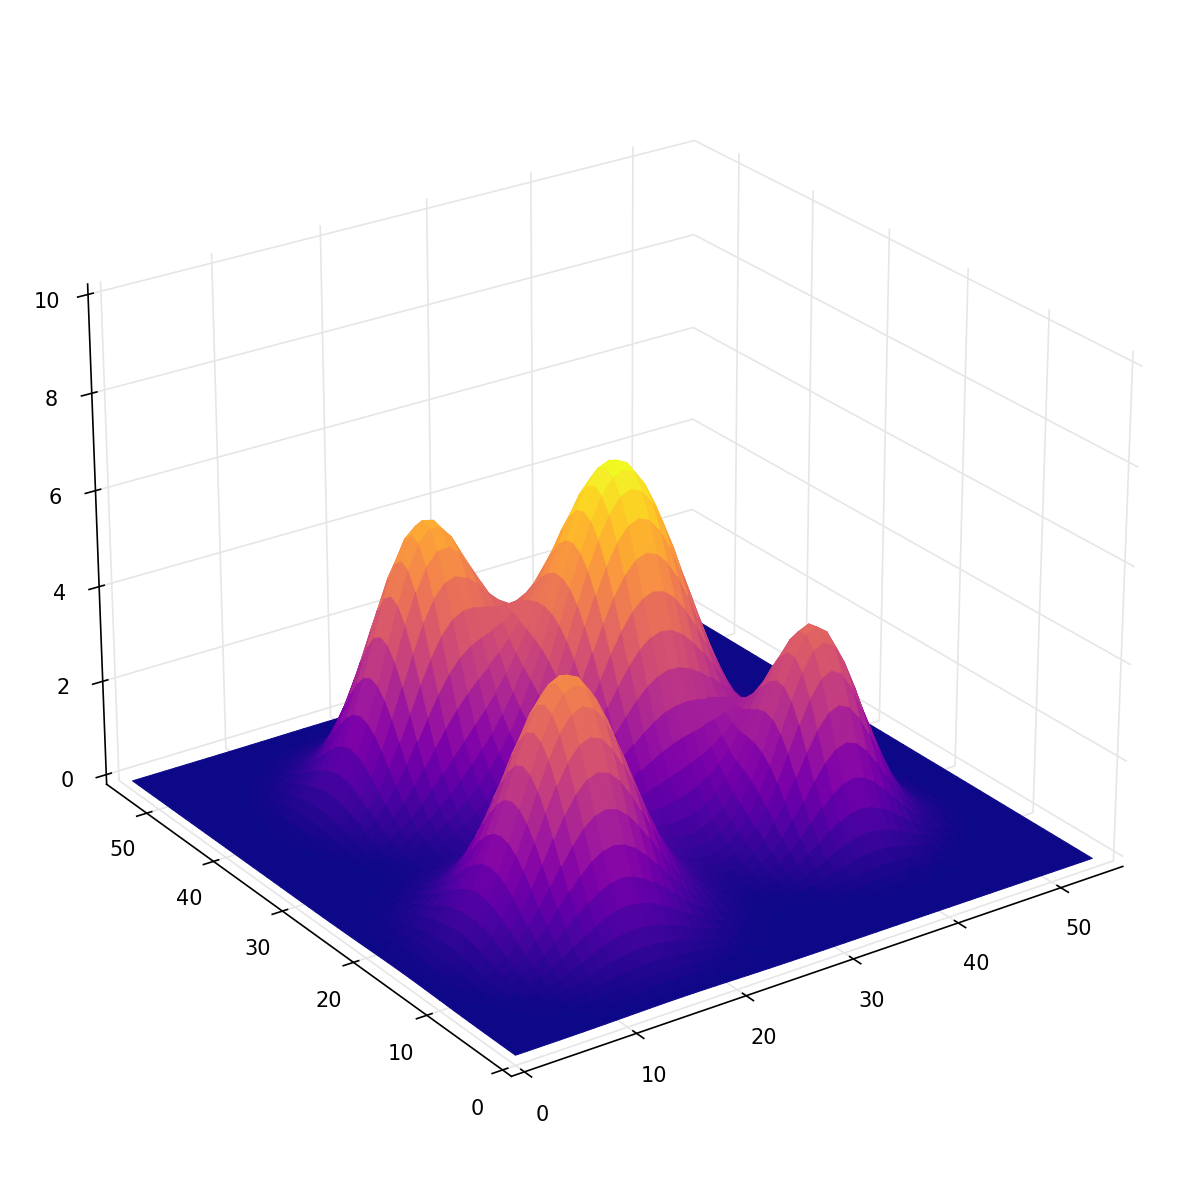

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps

# 1. Define a mathematically valid 5-peak Gaussian Mixture Model
def complex_likelihood_density(x, y):
    # Format: (x_center, y_center, amplitude, width_parameter)
    peaks_config = [
        (0.5, 0.5, 7.0, 1.8),     # Broad central peak
        (-2.0, -2.0, 5.0, 1.2),   # Mid-size bottom-left peak
        (2.0, -1.8, 4.2, 0.8),    # Sharp, narrow bottom-right peak
        (-1.5, 2.0, 5.5, 1.0),    # Tall top-left peak
        (2.2, 2.0, 3.5, 0.5)      # Very sharp, narrow top-right peak
    ]
    
    density = np.zeros_like(x)
    for xc, yc, amp, var in peaks_config:
        density += amp * np.exp(-((x - xc)**2 + (y - yc)**2) / var)
    return density

# 2. Grid setup
n = 55  # Slightly higher resolution to render more peaks smoothly
x = np.linspace(-4.5, 4.5, n)
y = np.linspace(-4.5, 4.5, n)
X_coord, Y_coord = np.meshgrid(x, y)
Z = complex_likelihood_density(X_coord, Y_coord)

# Plotting grid (indices 0 to n-1 for the clean axes style)
X, Y = np.meshgrid(np.arange(n), np.arange(n))

# 3. Create the 3D plot
fig = plt.figure(figsize=(10, 8), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# 4. Plot using the high-contrast 'plasma' colormap
surf = ax.plot_surface(X, Y, Z, 
                       cmap='plasma',      # High-contrast warm color scheme
                       linewidth=0.5, 
                       shade=False, 
                       rstride=1, cstride=1)

# Extract native colors and map them to the wireframe edges
array_data = surf.get_array() if surf.get_array() is not None else surf._A
edge_colors = surf.to_rgba(array_data)
surf.set_edgecolors(edge_colors)

# Turn the face colors to solid white to preserve the clean poster aesthetic
surf.set_facecolors('white')

# 5. Plot matching contour projection on the bottom plane (Z = 0)
ax.contour(X, Y, Z, zdir='z', offset=0, cmap='plasma', linewidths=1.2)

# 6. Formatting and limits
ax.set_zlim(0, 10)  # Extended limit to accommodate taller peak combinations
ax.set_xlim(0, n)
ax.set_ylim(0, n)

# Adjust camera perspective
ax.view_init(elev=25, azim=-125)

# Transparent panes for a clean design
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Light grey grids
ax.xaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1.0)
ax.yaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1.0)
ax.zaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1.0)

plt.tight_layout()
plt.show()

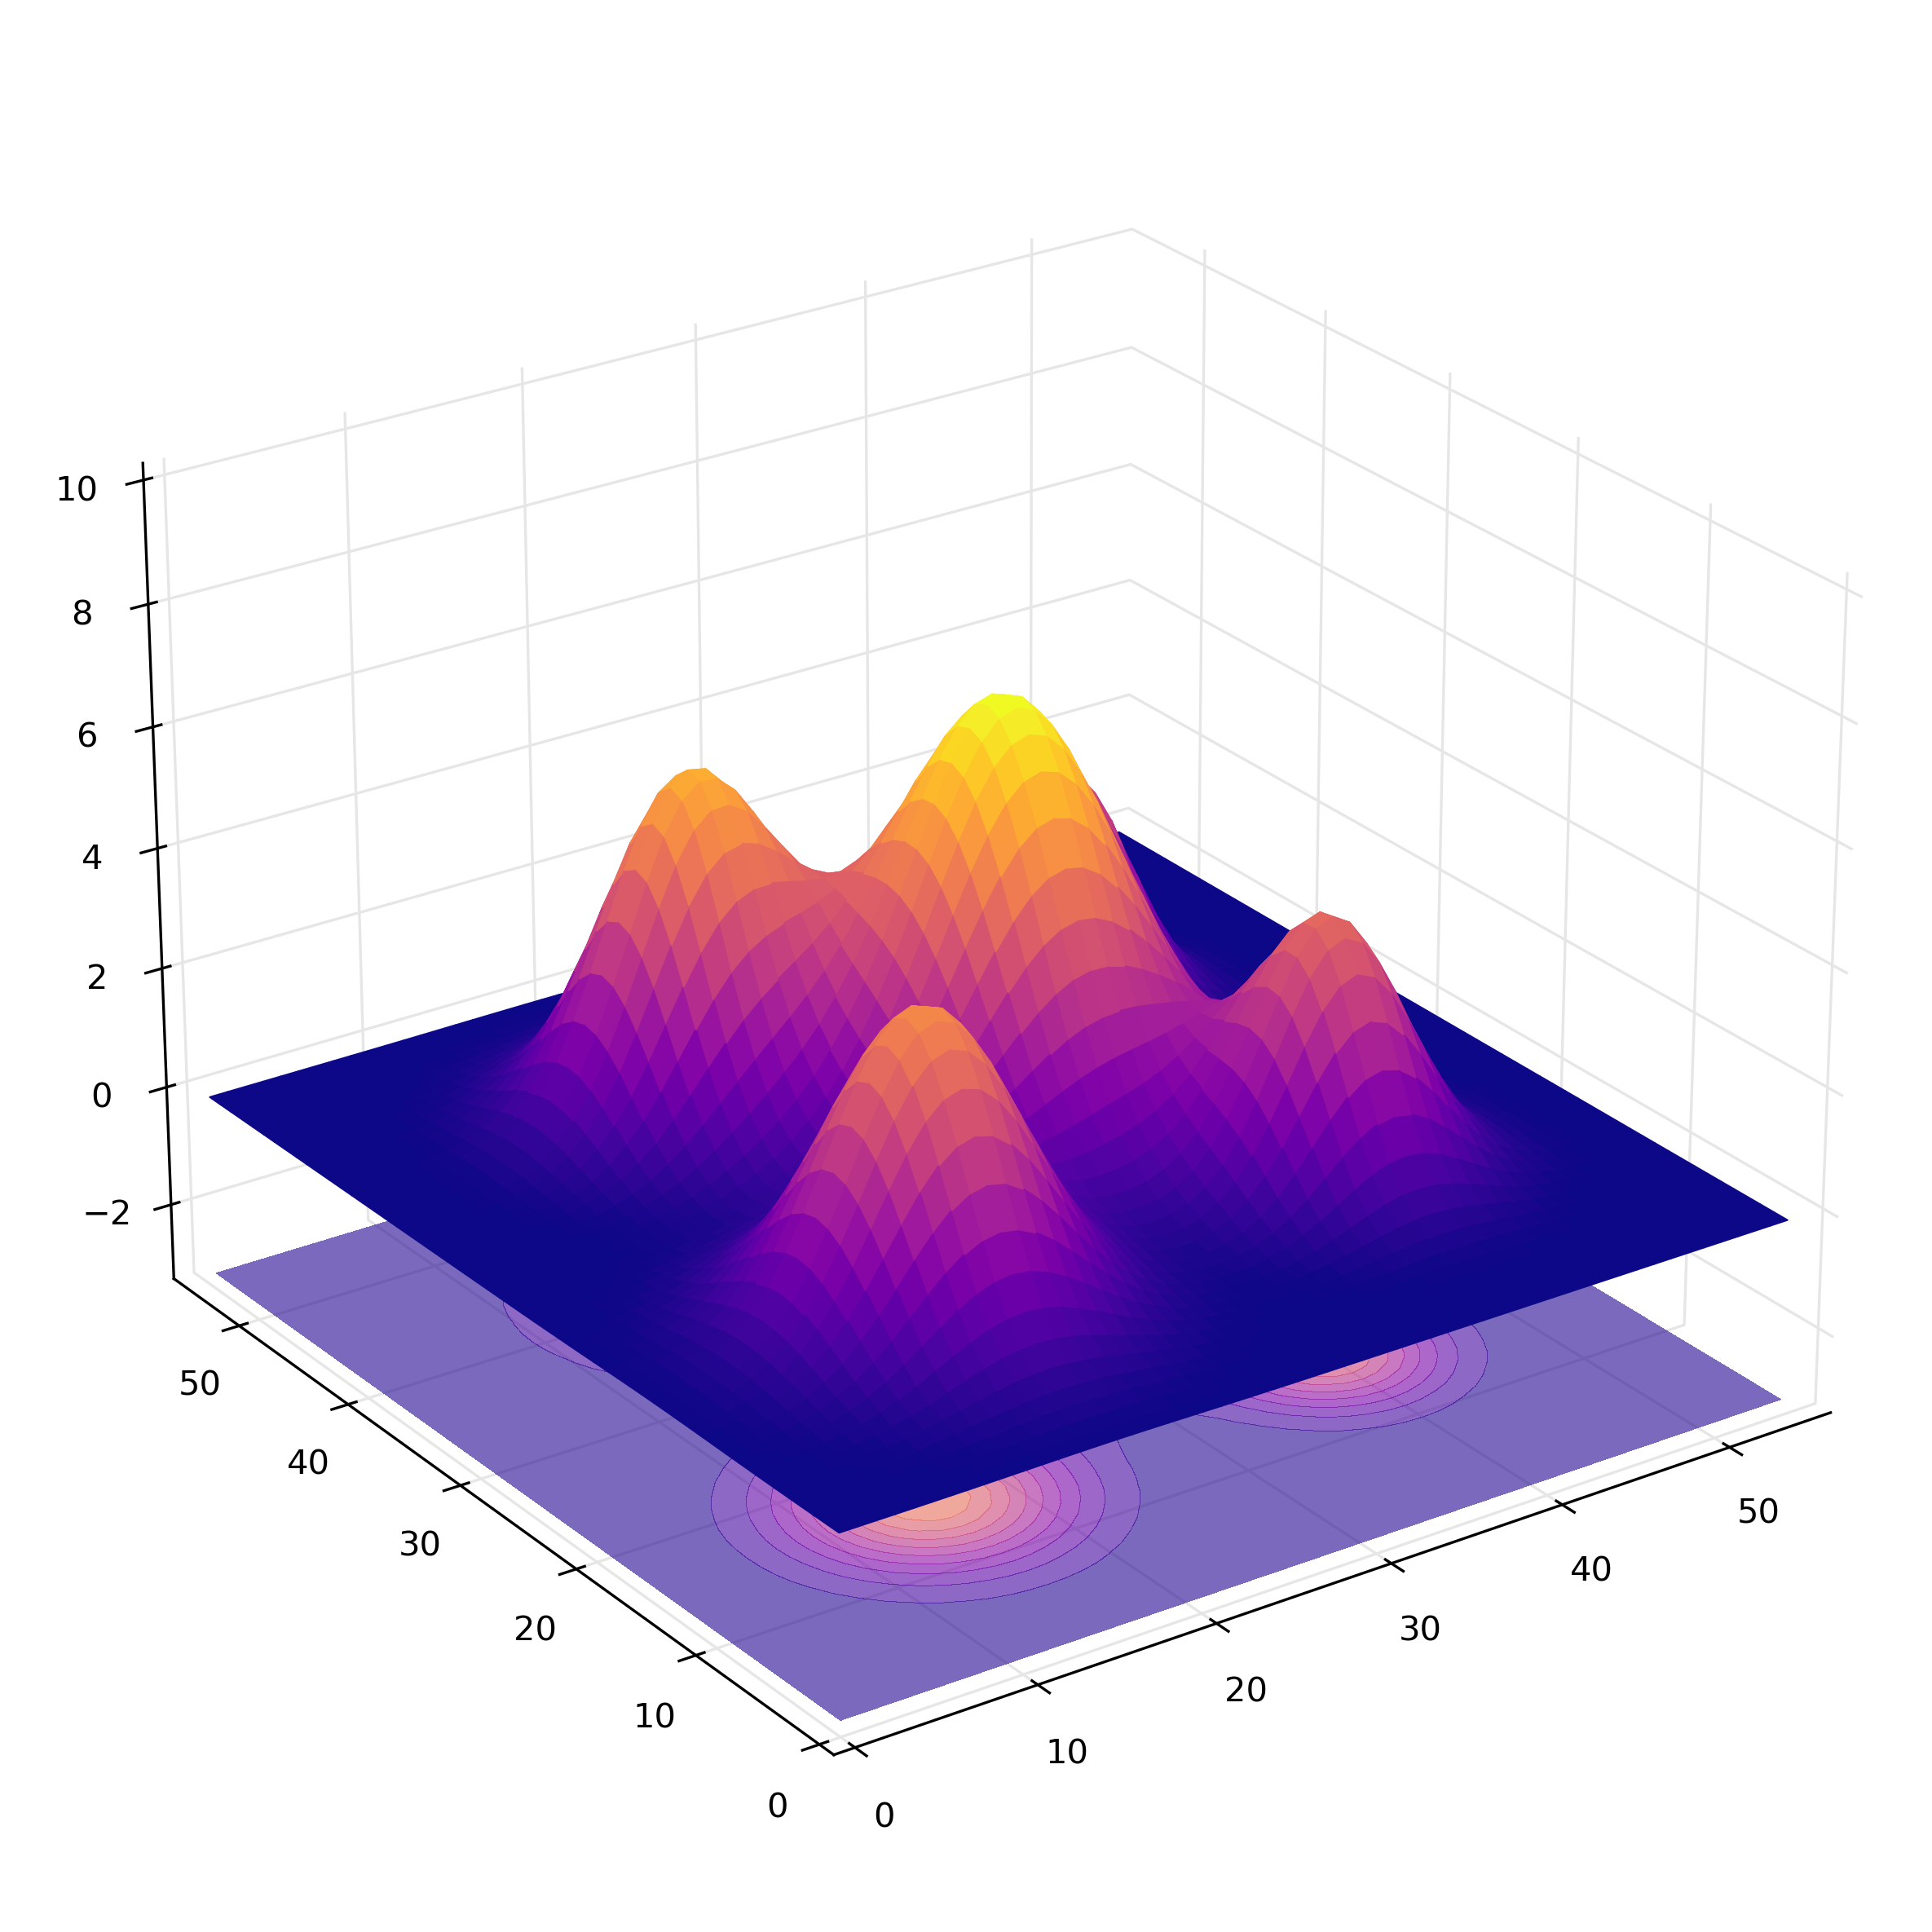

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps

# 1. Define the 5-peak Gaussian Mixture Model
def complex_likelihood_density(x, y):
    peaks_config = [
        (0.5, 0.5, 7.0, 1.8),     # Broad central peak
        (-2.0, -2.0, 5.0, 1.2),   # Bottom-left peak
        (2.0, -1.8, 4.2, 0.8),    # Bottom-right peak
        (-1.5, 2.0, 5.5, 1.0),    # Top-left peak
        (2.2, 2.0, 3.5, 0.5)      # Top-right peak
    ]
    
    density = np.zeros_like(x)
    for xc, yc, amp, var in peaks_config:
        density += amp * np.exp(-((x - xc)**2 + (y - yc)**2) / var)
    return density

# 2. Grid setup
n = 55  
x = np.linspace(-4.5, 4.5, n)
y = np.linspace(-4.5, 4.5, n)
X_coord, Y_coord = np.meshgrid(x, y)
Z = complex_likelihood_density(X_coord, Y_coord)

# Plotting grid (indices 0 to n-1)
X, Y = np.meshgrid(np.arange(n), np.arange(n))

# 3. Create the 3D plot
fig = plt.figure(figsize=(10, 8), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# 4. Plot the 3D WIREFRAME (colored lines with white/transparent faces)
surf = ax.plot_surface(X, Y, Z, 
                       cmap='plasma', 
                       linewidth=0.5, 
                       shade=False, 
                       rstride=1, cstride=1)

# Retrieve the mapped colors natively calculated by Matplotlib
array_data = surf.get_array() if surf.get_array() is not None else surf._A
edge_colors = surf.to_rgba(array_data)

# Assign the mapped colors directly to the wireframe edges
surf.set_edgecolors(edge_colors)

# Set the face colors to white with slight transparency (alpha=0.85)
# This keeps the wireframe clean and prevents it from fully blocking the floor
surf.set_facecolors((1.0, 1.0, 1.0, 0.85))

# 5. PLOT FILLED CONTOURS ON THE FLOOR (at Z = -3)
# This fills the space between the contour lines so they do not blend together
ax.contourf(X, Y, Z, zdir='z', offset=-3, cmap='plasma', alpha=0.6, levels=15)

# 6. Formatting and limits
ax.set_zlim(-3, 10)  # Starts at -3 so the Z=0 flat plane "floats" in the middle
ax.set_xlim(0, n)
ax.set_ylim(0, n)

# Adjust camera perspective
ax.view_init(elev=25, azim=-125)

# Transparent background panes
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Light grey grids
ax.xaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1.0)
ax.yaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1.0)
ax.zaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1.0)

plt.tight_layout()
plt.savefig("diagram.png", transparent=True)
plt.show()

In [7]:
from pocomc_mcmc import RStarPrior
a = RStarPrior(0.22924,0.004695)
s = a.rvs(size=5)



In [4]:
s[:, 4] + s[:, 5]

array([-0.64609276, -0.63305633, -0.64010562, -0.63570936, -0.62790721])

In [8]:
s

array([[ 2.01134707,  8.17903008, -0.79624751,  7.80259555,  0.72021945,
        -1.35521971, -0.44805579, -0.35187017],
       [ 1.11389776,  3.2142933 ,  1.77798344,  7.76073511,  1.6449715 ,
        -2.28702323,  1.27554101,  0.33494808],
       [ 0.68184303,  8.71766808,  0.21595848,  4.01409692,  1.77305147,
        -2.42723982,  0.96256055,  0.56803656],
       [ 2.96234614,  8.99829201,  0.49712505,  3.74745996, -0.38542961,
        -0.26036158,  0.45966384, -0.16011818],
       [ 2.68107966,  3.09086681, -0.29085952,  7.16779472,  0.65598084,
        -1.30823217,  2.83573893,  0.179859  ]])

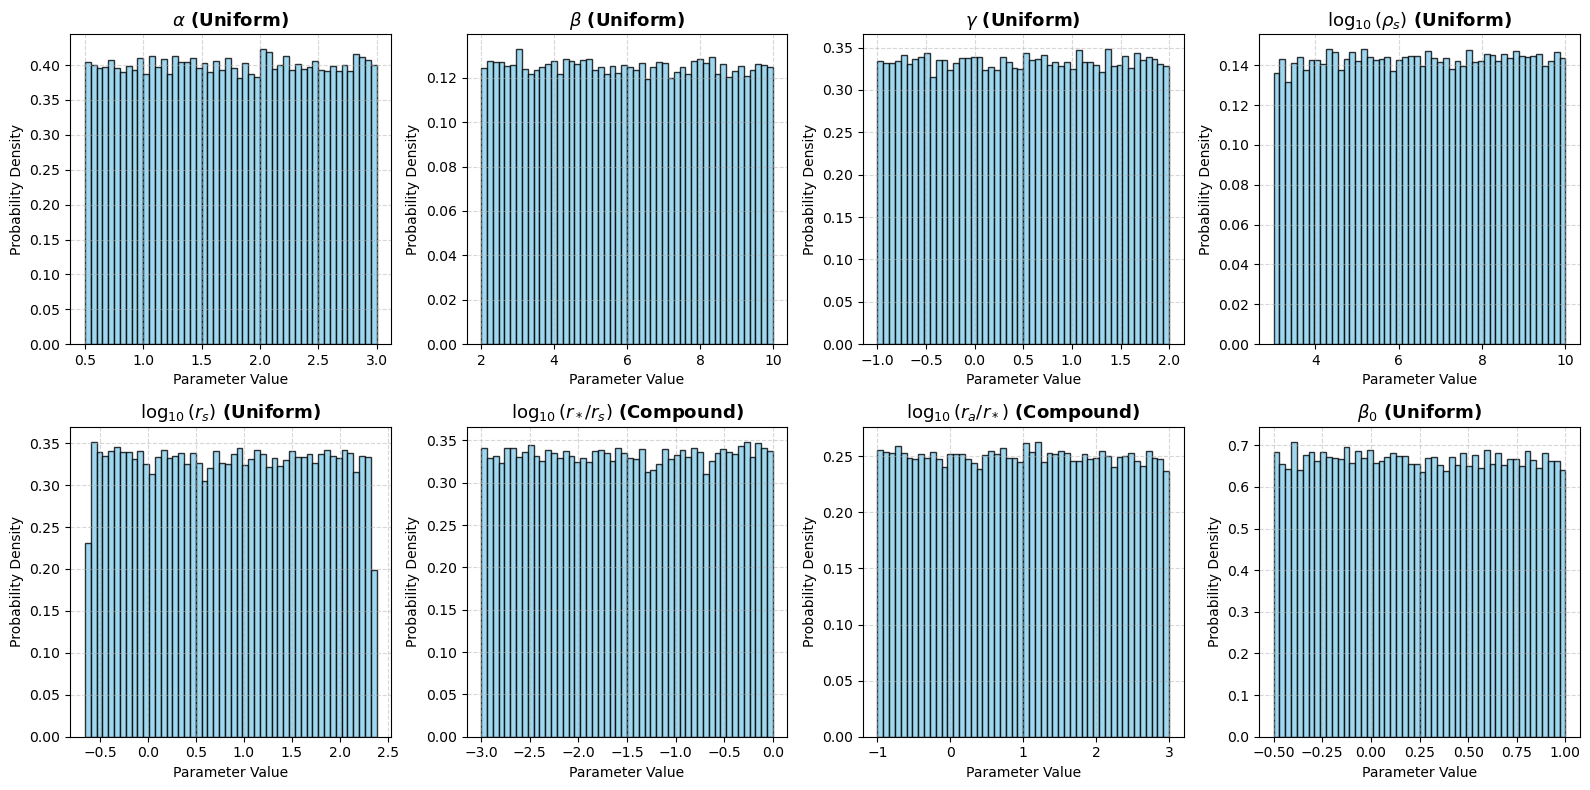

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pocomc_mcmc import RStarPrior

# 1. Initialize the prior with your target mean and uncertainty for r_star
prior = RStarPrior(r_star=0.22924, r_star_unc=0.004695)

# 2. Draw 10,000 samples to reconstruct smooth distributions
# (Your configuration module 'p' must be imported/available for the prior class to run)
samples = prior.rvs(size=100000)

# 3. Define the parameter labels for the 8 dimensions
labels = [
    r"$\alpha$ (Uniform)",
    r"$\beta$ (Uniform)",
    r"$\gamma$ (Uniform)",
    r"$\log_{10}(\rho_s)$ (Uniform)",
    r"$\log_{10}(r_s)$ (Uniform)",
    r"$\log_{10}(r_* / r_s)$ (Compound)",
    r"$\log_{10}(r_a / r_*)$ (Compound)",
    r"$\beta_0$ (Uniform)"
]

# 4. Set up a 2x4 grid of subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()  # Flatten the 2D axes grid to a 1D array of 8 subplots

# 5. Plot a histogram for each of the 8 parameters
for i in range(8):
    ax = axes[i]
    
    # Plot normalized density histogram
    ax.hist(
        samples[:, i], 
        bins=50, 
        density=True, 
        color='skyblue', 
        edgecolor='black', 
        alpha=0.8
    )
    
    # Custom styling
    ax.set_title(labels[i], fontsize=13, fontweight='bold')
    ax.set_xlabel("Parameter Value", fontsize=10)
    ax.set_ylabel("Probability Density", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

# Adjust layout to prevent label overlap
plt.tight_layout()
plt.show()